# SCRIPT PARA VISUALIZACIÓN Y GENRACIÓN DE COORDENADAS DE PERFILES NACA
Ete script sirve para visualizar de manera rapida las distintas configuraciones NACA
También sirve para generar un archivo xlsx e importar posteriormente sus coordenadas a un software de dibujo de manera precisa.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math
from ipywidgets import interact, IntSlider, fixed


def airfoilNACA(m,p,t,c,n):
    m = m / 100
    p = p / 10
    t = t / 100

    # === x distribution (cosine spacing) ===
    theta = np.linspace(0, np.pi, n)
    x = 0.5 * c * (1 - np.cos(theta))
    x_hat = x / c  # normalized x. Recuerda que c es la cuerda del perfil.

    # === Thickness distribution ===

    #Dado que el perfil queda abierto en su borde de fuga modificamos el ultimo parametro de la ecuacion  a
    # 0.1036 quedando asi el punto de fuga unido
    yt = 5*t*(0.2969*x_hat**(1/2) - 0.1260*x_hat - 0.3516*x_hat**2 + 0.2843*x_hat**3 - 0.1036*x_hat**4)

    # === Camber line and slope ===
    z = np.zeros_like(x)
    dzdx = np.zeros_like(x)

    #INCLUIMOS LAS ECUACIONES
    for i in range(len(x)):
        if x_hat[i] < p:
            z[i] =(m/(p**2))*(2*p*x_hat[i]-x_hat[i]**2)
            dzdx[i] =2*m/(p**2)*(p-x_hat[i])
        else:
            z[i] = m/(1-p)**2*(1-2*p+2*p*x_hat[i]-x_hat[i]**2)
            dzdx[i] = (2*m/(1-p)**2)*(p-x_hat[i])

    beta = math.atan(dzdx[i])


    # === Upper and lower airfoil coordinates ===
    xu = x-yt*math.sin(beta)
    yu = z+yt*math.cos(beta)
    xl = x+yt*math.sin(beta)
    yl = z-yt*math.cos(beta)


    # === Combine and plot ===
    x_total = np.concatenate([xu[::-1], xl[1:]])
    y_total = np.concatenate([yu[::-1], yl[1:]])
    plt.figure(figsize=(10, 4))
    plt.plot(x_total, y_total, 'k-', linewidth=1.5, label="Airfoil")
    plt.plot(x, z, 'r--', linewidth=1.2, label="Camber line")
    plt.axis('equal')
    plt.title(f"NACA {m*100:.0f}{p*10:.0f}{t*100:.0f}")
    plt.xlabel("x/c")
    plt.ylabel("y/c")
    plt.grid(True)
    plt.legend()
    plt.show()

    return x_total, y_total



#En cuanto al borde de ataque para redondearlo deberiamos de aproximar la curva de ataque a un circulo de radio r
# especificado abajo, dado que no se como dibujar el principio de la curva con la forma de ese circulo en este fragmento
# sobrepongo el circulo sobre el perfil para ver como deberia cambiar al suavizar el angulo de ataque.
#Como se puede observar en el caso del Perfil NACA 0012 no varia mucho el perfil
def airfoilNACA_circulo(m,p,t,c,n):
    m = m / 100
    p = p / 10
    t = t / 100

    # === x distribution (cosine spacing) ===
    theta = np.linspace(0, np.pi, n)
    x = 0.5 * c * (1 - np.cos(theta))
    x_hat = x / c  # normalized x. Recuerda que c es la cuerda del perfil.

    # === Thickness distribution ===
    yt = 5*t*(0.2969*x_hat**(1/2) - 0.1260*x_hat - 0.3516*x_hat**2 + 0.2843*x_hat**3 - 0.1036*x_hat**4)

    # === Camber line and slope ===
    z = np.zeros_like(x)
    dzdx = np.zeros_like(x)

    #INCLUIMOS LAS ECUACIONES
    for i in range(len(x)):
        if x_hat[i] < p:
            z[i] =(m/(p**2))*(2*p*x_hat[i]-x_hat[i]**2)
            dzdx[i] =2*m/(p**2)*(p-x_hat[i])
        else:
            z[i] = m/(1-p)**2*(1-2*p+2*p*x_hat[i]-x_hat[i]**2)
            dzdx[i] = (2*m/(1-p)**2)*(p-x_hat[i])

    beta = math.atan(dzdx[i])


    # === Upper and lower airfoil coordinates ===
    xu = x-yt*math.sin(beta)
    yu = z+yt*math.cos(beta)
    xl = x+yt*math.sin(beta)
    yl = z-yt*math.cos(beta)


    # === Combine and plot ===
    x_total = np.concatenate([xu[::-1], xl[1:]])
    y_total = np.concatenate([yu[::-1], yl[1:]])
    plt.figure(figsize=(10, 4))
    plt.plot(x_total, y_total, 'k-', linewidth=1.5, label="Airfoil")
    plt.plot(x, z, 'r--', linewidth=1.2, label="Camber line")

    #AÑADIMOS EL CIRCULO
    r = 1.1019 * (t**2)
    ax = plt.gca()
    circulo = plt.Circle((r, 0), radius=r, color='blue', fill=False, linewidth=1.8, label='Círculo')
    ax.add_patch(circulo)

    plt.axis('equal')
    plt.title(f"NACA {m*100:.0f}{p*10:.0f}{t*100:.0f}")
    plt.xlabel("x/c")
    plt.ylabel("y/c")
    plt.grid(True)
    plt.legend()
    plt.show()

    return x_total, y_total

# === Envoltorio sin return ===
def plot_airfoil(m,p,t,c,n):
    airfoilNACA_circulo(m,p,t,c,n)


# === Sliders interactivos ===
interact(
    plot_airfoil,
    m=IntSlider(min=0, max=9, step=1, value=2, description="m"),
    p=IntSlider(min=0, max=9, step=1, value=4, description="p"),
    t=IntSlider(min=10, max=40, step=1, value=12, description="t"),
    c=fixed(1.0),  # cuerda
    n=fixed(200)   # número de puntos
)

interactive(children=(IntSlider(value=2, description='m', max=9), IntSlider(value=4, description='p', max=9), …

<function __main__.plot_airfoil(m, p, t, c, n)>

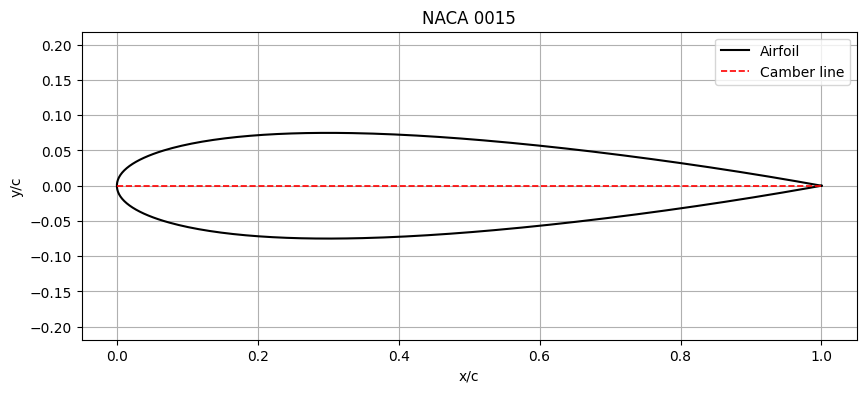

Airfoil coordinates saved to airfoil_coordinates.txt


In [ ]:
x, y = airfoilNACA(m=0, p=0, t=15, c=1.0, n=200)

#guarda la salida en txt o csv
import pandas as pd

df = pd.DataFrame({'x': x, 'y': y, 'z': 0})

# Save to .txt format with only x and y columns
df[['x', 'y']].to_csv('NACA_0015.txt', sep=' ', index=False)

print("Airfoil coordinates saved to airfoil_coordinates.txt")

In [ ]:
df.to_excel('NACA_0015.xlsx', index=False)
print("Airfoil coordinates saved to NACA_0015.xlsx")

Airfoil coordinates saved to NACA_0018.xlsx
